In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_event_history(filepath: str, trial: int = 0) -> dict:
    """JSONLファイルからイベント履歴を読み込む"""
    with open(filepath, "r") as f:
        data = [json.loads(line) for line in f]
    
    trial_data = data[trial]
    events = trial_data["events"]
    
    if isinstance(events, dict):
        return events
    else:
        return {e[0]: e[1] for e in events}

def plot_cumulative_events(
    event_dict: dict,
    event_names: list[str] | None = None,
    figsize: tuple = (12, 6),
    title: str = "Event Firing History"
):
    """
    イベント発火の累積回数をプロット
    
    Args:
        event_dict: {event_name: [steps...]} の辞書
        event_names: プロットするイベント名のリスト（Noneなら全イベント）
        figsize: 図のサイズ
        title: グラフタイトル
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    if event_names is None:
        event_names = list(event_dict.keys())
    
    for event_name in event_names:
        if event_name not in event_dict:
            print(f"Warning: '{event_name}' not found in event_dict")
            continue
        
        steps = event_dict[event_name]
        if len(steps) == 0:
            continue
        
        steps_sorted = sorted(steps)
        cumulative = np.arange(1, len(steps_sorted) + 1)
        ax.step(steps_sorted, cumulative, where='post', label=event_name)
    
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Firings")
    ax.set_title(title)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


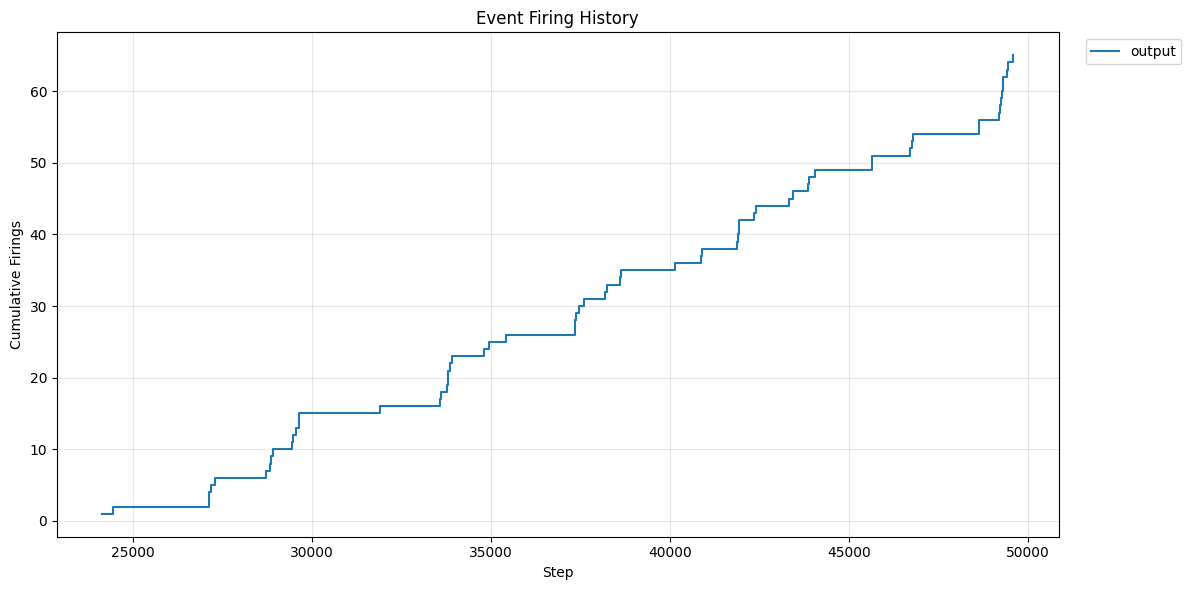

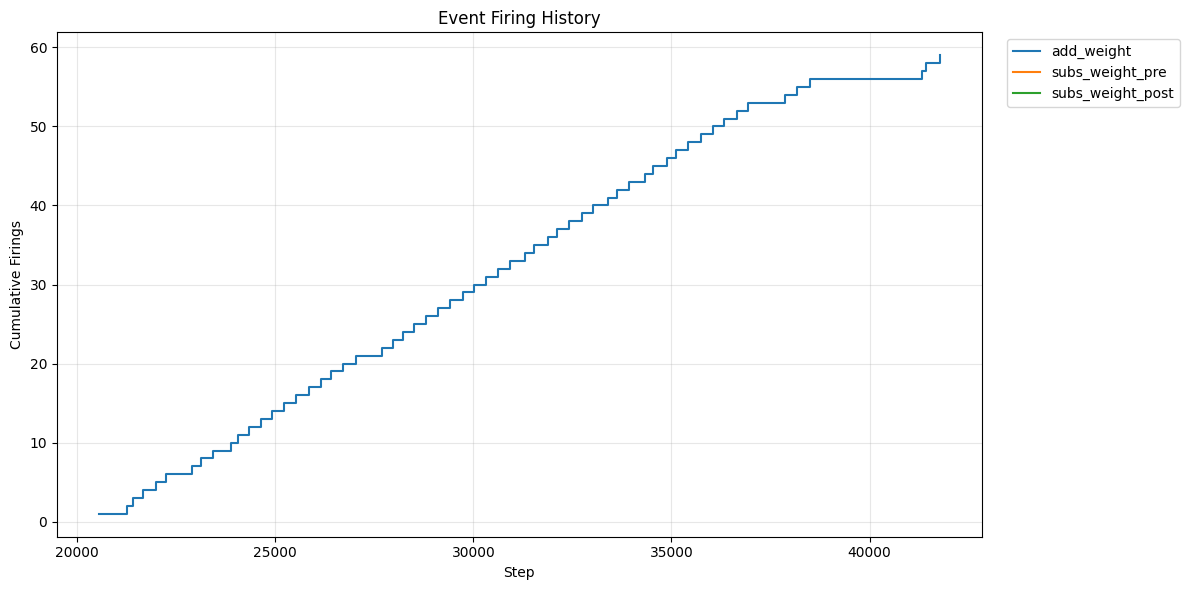

In [9]:
event_dict = load_event_history("event_history.jsonl", trial=0)

plot_cumulative_events(event_dict, event_names=["output"])
plot_cumulative_events(event_dict, event_names=["add_weight", "subs_weight_pre", "subs_weight_post"])